# 📌 Bölüm 0: Başlangıç Notları ve Hızlı Alıştırmalar (Orijinal Kodlar)
Aşağıdaki kod hücreleri konuya giriş niteliğinde hazırlanan ilk notları ve alıştırmaları içermektedir.

In [5]:
#Normal Dağılım(Gaussian Distribution) İstatistikte gördüğümüz en yaygın dağılım fonksiyonu.
# Veri kümesinin çoğunluğu ortalamaya yakındır
# Çan eğrisi şeklindedir
# mean median mode birbirine eşittir

# insan boyları(1000 kişi) mean 170 std = 10cm
# 140cm-200 cm
# insan kiloları(1000 kişi)
# 45-120kg

# Normal Dağılım pmf midir pdf midir? pdf
#P(160 < X < 180) = %65
#P(150 < X < 190) = %95  
#P(140 < X < 200) = %99.7    

In [ ]:
# z-score bir değerin ortalamadan kaç std uzaklaştıgını bulur
#age(0-100), kilo(45-150) boy(140-200), maas(22500-200000)
import numpy as np

data = np.array([60,65,70,75,80,85,90])
mean = np.mean(data)
std = np.std(data)

print(mean)
print(std)

z_scores = (data - mean) / std
print(z_scores)

75.0
10.0
[-1.5 -1.  -0.5  0.   0.5  1.   1.5]


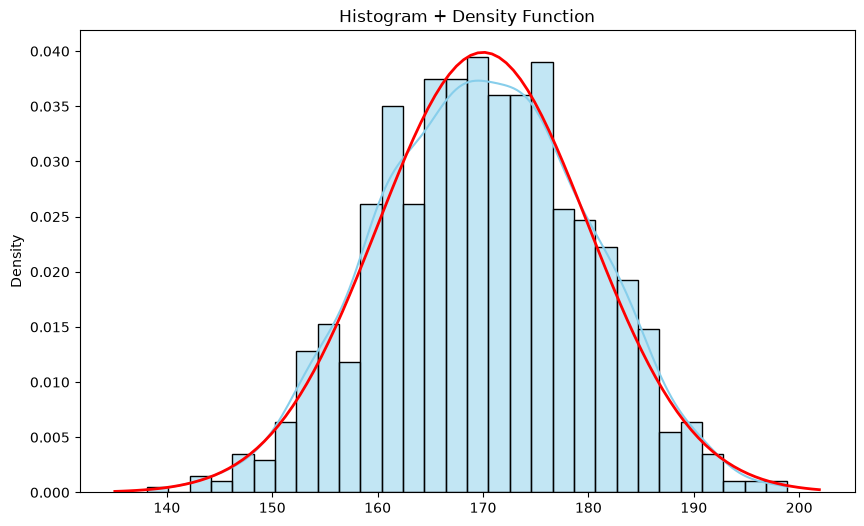

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

np.random.seed(20)
data = np.random.normal(loc = 170, scale = 10, size = 1000)

# Histogram + PDF
plt.figure(figsize=(10,6))
sns.histplot(data, bins=30, kde=True, stat="density", color='skyblue', edgecolor='black')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, 170, 10)
plt.plot(x,p,color = "red", linewidth=2, label = "Normal Distribution")
plt.title("Histogram + Density Function")
plt.show()

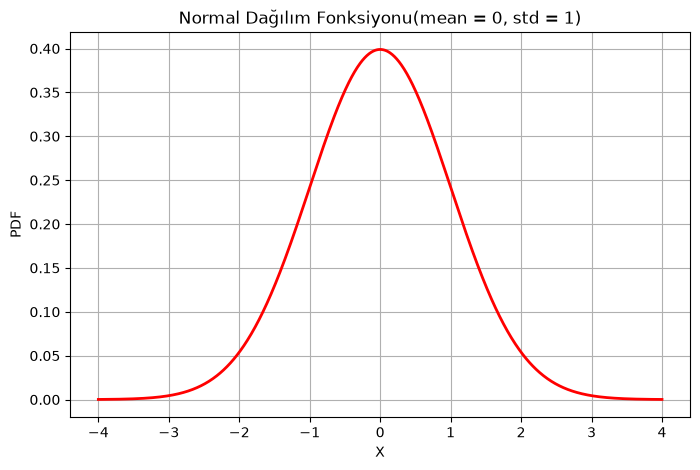

In [9]:
# Ortalaması 0, standart sapması 1 olan standard normal dağılım
# PDF (Probability Density Function) eğrisini çizen bir Python kodu yazınız
# x değerleri -4 ile 4 arasında olmalıdır

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-4, 4, 1000)
pdf = norm.pdf(x, 0, 1)

plt.figure(figsize=(8,5))
plt.plot(x, pdf, color='red', linewidth=2)
plt.title("Normal Dağılım Fonksiyonu(mean = 0, std = 1)")
plt.xlabel("X")
plt.ylabel("PDF")
plt.grid(True)
plt.show()

---
# 📚 NORMAL (GAUSS) DAĞILIMI - KAPSAMLI TEORİ VE UYGULAMA REHBERİ
### Olasılık Dağılımları Serisi - Sürekli Dağılımlar (Continuous Distributions)

---

## 📌 1. Giriş ve Sezgisel Açıklama

**Normal Dağılım (Normal / Gaussian Distribution)** veya halk arasında bilinen adıyla **Çan Eğrisi (Bell Curve)**, doğada, sosyal bilimlerde, mühendislikte ve veri biliminde en sık karşılaşılan sürekli olasılık dağılımıdır.

Carl Friedrich Gauss ve Abraham de Moivre'ın çalışmalarıyla geliştirilen bu dağılımın temel özellikleri:
1. **Mükemmel Simetri:** Dağılım $\mu$ (ortalama) noktasına göre tamamen simetriktir.
2. **Merkezi Eğilim:** Verilerin en büyük kısmı ortalama etrafında toplanır. Ortalamadan uzaklaştıkça değerlerin ortaya çıkma olasılığı hızla sıfıra yaklaşır.
3. **Üçlünün Eşitliği:** $	ext{Ortalama} = 	ext{Medyan} = 	ext{Mod} = \mu$
4. **Kuyruklar (Asimptotik Yapı):** Eğrinin iki ucu sonsuza ($-\infty, +\infty$) kadar uzanır ancak x-eksenine asla dokunmaz ($f(x) > 0$).
5. **Toplam Alan:** Eğrinin altındaki toplam alan (tüm olasılıkların toplamı) tam olarak **$1.0$ (%100)**'dir.

---
## 📐 2. Matematiksel Tanım ve Olasılık Yoğunluk Fonksiyonu (PDF)

Normal dağılıma sahip sürekli bir rastgele değişken $X \sim \mathcal{N}(\mu, \sigma^2)$ olarak gösterilir.

### 🔹 Olasılık Yoğunluk Fonksiyonu (PDF):
$$f(x) = rac{1}{\sigma \sqrt{2\pi}} \exp\left( -rac{1}{2} \left( rac{x - \mu}{\sigma} ight)^2 ight) = rac{1}{\sigma \sqrt{2\pi}} e^{-rac{(x - \mu)^2}{2\sigma^2}}, \quad x \in (-\infty, +\infty)$$

Burada:
- $\mu$ (**Mean / Konum Parametresi**): Dağılımın merkezini ve zirve noktasını belirler.
- $\sigma$ (**Standard Deviation / Ölçek Parametresi**): Dağılımın yayılımını (genişliğini/basıklığını) belirler ($\sigma > 0$).
- $\sigma^2$ (**Varyans**): Değerlerin ortalamadan sapma derecesi.
- $\pi pprox 3.14159$ ve $e pprox 2.71828$ matematiksel sabitlerdir.

---

### 🔹 Kümülatif Dağılım Fonksiyonu (CDF):
Bir $X$ değerinin $x$'e eşit veya $x$'ten küçük olma olasılığı:
$$F(x) = P(X \le x) = \int_{-\infty}^{x} rac{1}{\sigma \sqrt{2\pi}} e^{-rac{(t-\mu)^2}{2\sigma^2}} dt = rac{1}{2} \left[ 1 + 	ext{erf}\left( rac{x - \mu}{\sigma \sqrt{2}} ight) ight]$$

*(Burada $	ext{erf}$ hata fonksiyonudur (error function).)*

---

### 📊 İstatistiksel Özellikler ve Momentler

| İstatistiksel Metrik | Formül | Açıklama |
| :--- | :--- | :--- |
| **Beklenen Değer (Mean)** | $E[X] = \mu$ | Dağılımın ağırlık merkezi ve tepe noktası |
| **Medyan (Median)** | $	ext{Medyan} = \mu$ | Veriyi iki eşit yarıya bölen değer |
| **Mod (Mode)** | $	ext{Mod} = \mu$ | En yüksek olasılık yoğunluğuna sahip nokta |
| **Varyans (Variance)** | $	ext{Var}(X) = \sigma^2$ | Değişkenliğin ölçüsü |
| **Standart Sapma** | $	ext{Std}(X) = \sigma$ | Ortalamadan ortalama sapma mesafesi |
| **Çarpıklık (Skewness)** | $\gamma_1 = 0$ | Mükemmel simetriktir, çarpıklık yoktur |
| **Basıklık (Kurtosis)** | $eta_2 = 3 \quad (	ext{Excess Kurtosis} = 0)$ | Mezokurtik referans eğridir |

---
## 💻 3. Python Ortam Hazırlığı ve Kütüphaneler

In [ ]:
# Gerekli bilimsel kütüphanelerin import edilmesi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm

# Grafik estetik ayarları
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

print("✅ Kütüphaneler başarıyla yüklendi ve grafik ortamı hazırlandı.")

---
## 🎯 4. 68-95-99.7 Ampirik Kuralı (Empirical Rule / 3-Sigma Kuralı)

Normal dağılımın en kritik pratik kuralı **3-Sigma Kuralı**dır:
- **$\mu \pm 1\sigma$ aralığı:** Verilerin yaklaşık **%68.27**'sini içerir: $P(\mu - \sigma \le X \le \mu + \sigma) pprox 0.6827$
- **$\mu \pm 2\sigma$ aralığı:** Verilerin yaklaşık **%95.45**'ini içerir: $P(\mu - 2\sigma \le X \le \mu + 2\sigma) pprox 0.9545$
- **$\mu \pm 3\sigma$ aralığı:** Verilerin yaklaşık **%99.73**'ünü içerir: $P(\mu - 3\sigma \le X \le \mu + 3\sigma) pprox 0.9973$
- $3\sigma$'nın ötesindeki değerler (kalan %0.27) pratikte **ekstrem / aykırı değer (outlier)** olarak değerlendirilir.

In [ ]:
# 68-95-99.7 Kuralının SciPy ile Tam Olasılık Değerlerinin Hesaplanması
mu = 0
sigma = 1

prob_1sigma = norm.cdf(mu + 1*sigma, mu, sigma) - norm.cdf(mu - 1*sigma, mu, sigma)
prob_2sigma = norm.cdf(mu + 2*sigma, mu, sigma) - norm.cdf(mu - 2*sigma, mu, sigma)
prob_3sigma = norm.cdf(mu + 3*sigma, mu, sigma) - norm.cdf(mu - 3*sigma, mu, sigma)

print(f"🔹 [μ - 1σ, μ + 1σ] Alanı : %{prob_1sigma * 100:.2f}  (Tam: {prob_1sigma:.6f})")
print(f"🔹 [μ - 2σ, μ + 2σ] Alanı : %{prob_2sigma * 100:.2f}  (Tam: {prob_2sigma:.6f})")
print(f"🔹 [μ - 3σ, μ + 3σ] Alanı : %{prob_3sigma * 100:.2f}  (Tam: {prob_3sigma:.6f})")

---
## 🔬 5. SciPy ile Normal Dağılım Fonksiyonları (PDF, CDF, PPF, SF, Interval, Fit)

`scipy.stats.norm` sınıfı normal dağılım ile ilgili zengin fonksiyon seti sunar:
- `norm.pdf(x, loc, scale)`: Verilen $x$ noktasındaki olasılık yoğunluk değeri.
- `norm.cdf(x, loc, scale)`: $P(X \le x)$ birikimli olasılığı (Sol kuyruk alanı).
- `norm.sf(x, loc, scale)`: $P(X > x) = 1 - 	ext{CDF}(x)$ hayatta kalma / sağ kuyruk olasılığı.
- `norm.ppf(q, loc, scale)`: Yüzdelik dilim değeri (Quantile/Percent Point Function, CDF'in tersi).
- `norm.interval(confidence, loc, scale)`: İstenen güven düzeyine karşılık gelen simetrik aralık ($[x_1, x_2]$).
- `norm.rvs(loc, scale, size)`: Normal dağılıma uygun rastgele veri üretimi.
- `norm.fit(data)`: Ham veriden En Çok Olabilirlik (MLE) ile $\mu$ ve $\sigma$ parametrelerini tahmin etme.

In [ ]:
# Örnek: Ortalama boy 170 cm, standart sapma 10 cm olan bir popülasyon
mu_boy = 170
sigma_boy = 10

# 1. 185 cm'den KISA olma olasılığı P(X <= 185)
p_kisa_185 = norm.cdf(185, loc=mu_boy, scale=sigma_boy)

# 2. 185 cm'den UZUN olma olasılığı P(X > 185)
p_uzun_185 = norm.sf(185, loc=mu_boy, scale=sigma_boy)

# 3. Popülasyonun en uzun %10'luk dilimine girmek için minimum boy (90. Persentil)
boy_p90 = norm.ppf(0.90, loc=mu_boy, scale=sigma_boy)

# 4. Popülasyonun ortadaki %95'inin boy aralığı
boy_aralik_95 = norm.interval(0.95, loc=mu_boy, scale=sigma_boy)

# 5. Veri Üretimi ve Parametre Tahmini (Fit)
sim_data = norm.rvs(loc=mu_boy, scale=sigma_boy, size=5000, random_state=42)
tahmin_mu, tahmin_sigma = norm.fit(sim_data)

print(f"1. Boyun <= 185 cm olma olasılığı P(X <= 185)  : %{p_kisa_185*100:.2f}")
print(f"2. Boyun > 185 cm olma olasılığı P(X > 185)    : %{p_uzun_185*100:.2f}")
print(f"3. En uzun %10'a girmek için gereken boy (P90) : {boy_p90:.2f} cm")
print(f"4. Popülasyonun %95 Güven Aralığı             : [{boy_aralik_95[0]:.2f} cm, {boy_aralik_95[1]:.2f} cm]")
print(f"5. 5.000 Örneklemden Tahmin Edilen Parametreler: μ={tahmin_mu:.2f}, σ={tahmin_sigma:.2f}")

---
## 📈 6. Kapsamlı ve Estetik Görselleştirmeler

### 🎨 Grafik 1: Farklı $\mu$ ve $\sigma$ Parametrelerinin Çan Eğrisine Etkisi

In [ ]:
x_axis = np.linspace(-10, 20, 1000)

configs = [
    {"mu": 0, "sigma": 1.0, "color": "#1f77b4", "label": "μ=0, σ=1.0 (Standart Normal)"},
    {"mu": 0, "sigma": 2.5, "color": "#ff7f0e", "label": "μ=0, σ=2.5 (Geniş / Yayvan)"},
    {"mu": 0, "sigma": 0.5, "color": "#2ca02c", "label": "μ=0, σ=0.5 (Sivri / Dar)"},
    {"mu": 5, "sigma": 1.5, "color": "#d62728", "label": "μ=5, σ=1.5 (Sağa Kaydırılmış)"}
]

plt.figure(figsize=(12, 6))
for cfg in configs:
    pdf_vals = norm.pdf(x_axis, loc=cfg["mu"], scale=cfg["sigma"])
    plt.plot(x_axis, pdf_vals, label=cfg["label"], color=cfg["color"], linewidth=2.5)

plt.title("Normal Dağılım: Farklı μ (Konum) ve σ (Yayılım) Parametrelerinin Karşılaştırılması", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("x Değeri", fontsize=11)
plt.ylabel("Olasılık Yoğunluğu f(x)", fontsize=11)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 🎨 Grafik 2: 3-Sigma Kuralının Renkli Alan Gölgelendirmesi (%68.3, %95.4, %99.7)

In [ ]:
mu = 100
sigma = 15
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

plt.figure(figsize=(12, 6))
plt.plot(x, y, color='#2c3e50', linewidth=2.5, label='Normal Dağılım N(100, 15²)')

# 3-Sigma Alanı (%99.73)
mask_3s = (x >= mu - 3*sigma) & (x <= mu + 3*sigma)
plt.fill_between(x[mask_3s], y[mask_3s], color='#3498db', alpha=0.3, label='μ ± 3σ (%99.73)')

# 2-Sigma Alanı (%95.45)
mask_2s = (x >= mu - 2*sigma) & (x <= mu + 2*sigma)
plt.fill_between(x[mask_2s], y[mask_2s], color='#2ecc71', alpha=0.4, label='μ ± 2σ (%95.45)')

# 1-Sigma Alanı (%68.27)
mask_1s = (x >= mu - 1*sigma) & (x <= mu + 1*sigma)
plt.fill_between(x[mask_1s], y[mask_1s], color='#f1c40f', alpha=0.6, label='μ ± 1σ (%68.27)')

# Ortalama ve Sigma dikey çizgileri
plt.axvline(mu, color='#e74c3c', linestyle='--', linewidth=2, label=f'Ortalama μ = {mu}')
for k in [-3, -2, -1, 1, 2, 3]:
    plt.axvline(mu + k*sigma, color='gray', linestyle=':', alpha=0.7)

plt.title("68 - 95 - 99.7 Ampirik Kuralı (Empirical / 3-Sigma Rule)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("IQ Puanı (Örnek: μ=100, σ=15)", fontsize=11)
plt.ylabel("Olasılık Yoğunluğu f(x)", fontsize=11)
plt.legend(loc='upper right', frameon=True, facecolor='white', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 🎨 Grafik 3: PDF ve Birikimli Dağılım Fonksiyonu (CDF) Yan Yana Analizi

In [ ]:
x_eval = np.linspace(-4, 4, 500)
pdf_eval = norm.pdf(x_eval, 0, 1)
cdf_eval = norm.cdf(x_eval, 0, 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Sol Subplot: PDF ve Belirli Bölge İntegrali
ax1.plot(x_eval, pdf_eval, color='#2980b9', linewidth=2.5, label='PDF f(x)')
ax1.fill_between(x_eval, pdf_eval, where=(x_eval <= 1.0), color='#3498db', alpha=0.4, label='P(X ≤ 1.0) Alanı')
ax1.axvline(1.0, color='#e74c3c', linestyle='--', label='x = 1.0')
ax1.set_title("Olasılık Yoğunluk Fonksiyonu (PDF): Alan = Olasılık", fontsize=12, fontweight='bold')
ax1.set_xlabel("x")
ax1.set_ylabel("f(x)")
ax1.legend(frameon=True, facecolor='white')
ax1.grid(True, linestyle='--', alpha=0.6)

# Sağ Subplot: CDF
ax2.plot(x_eval, cdf_eval, color='#8e44ad', linewidth=2.5, label='CDF F(x) = P(X ≤ x)')
ax2.scatter([1.0], [norm.cdf(1.0)], color='#e74c3c', s=70, zorder=5)
ax2.hlines(norm.cdf(1.0), -4, 1.0, color='#e74c3c', linestyle='--')
ax2.vlines(1.0, 0, norm.cdf(1.0), color='#e74c3c', linestyle='--')
ax2.annotate(f'F(1.0) ≈ {norm.cdf(1.0):.4f}', xy=(1.0, norm.cdf(1.0)), xytext=(1.3, 0.7),
             arrowprops=dict(arrowstyle="->", color='black'), fontsize=10, fontweight='bold')
ax2.set_title("Kümülatif Dağılım Fonksiyonu (CDF): 0'dan 1'e Monoton Artan", fontsize=12, fontweight='bold')
ax2.set_xlabel("x")
ax2.set_ylabel("F(x)")
ax2.set_ylim(0, 1.05)
ax2.legend(frameon=True, facecolor='white')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### 🎨 Grafik 4: Q-Q Plot (Quantile-Quantile Grafiği) ve Normallik Testleri

Veri biliminde bir veri setinin normal dağılıma uyup uymadığını kontrol etmek için **Q-Q Plot** ve istatistiksel hipotez testleri (**Shapiro-Wilk**, **D'Agostino's $K^2$**) kullanılır.

In [ ]:
np.random.seed(42)
normal_orneklem = np.random.normal(loc=50, scale=10, size=500)
carpik_orneklem = np.random.exponential(scale=10, size=500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Normal Veri Q-Q Plot
stats.probplot(normal_orneklem, dist="norm", plot=ax1)
ax1.set_title("Q-Q Plot: Normal Dağılan Veri (Doğrusal Uyum)", fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)

# Çarpık Veri Q-Q Plot
stats.probplot(carpik_orneklem, dist="norm", plot=ax2)
ax2.set_title("Q-Q Plot: Normal Olmayan (Üstel) Veri (Kavisli Sapma)", fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# İstatistiksel Hipotez Testi (Shapiro-Wilk Testi)
# H0: Veri normal dağılıma uygundur. (p > 0.05 ise normallik reddedilemez)
stat_norm, p_norm = stats.shapiro(normal_orneklem)
stat_exp, p_exp = stats.shapiro(carpik_orneklem)

print(f"📊 Normal Veri İçin Shapiro-Wilk Testi  : İstatistik={stat_norm:.4f}, p-değeri={p_norm:.4e} -> {'✅ Normal Dağılım' if p_norm > 0.05 else '❌ Normal Değil'}")
print(f"📊 Çarpık Veri İçin Shapiro-Wilk Testi  : İstatistik={stat_exp:.4f}, p-değeri={p_exp:.4e} -> {'✅ Normal Dağılım' if p_exp > 0.05 else '❌ Normal Değil'}")

---
## 💼 7. Gerçek Hayat Senaryoları ve Vaka Analizleri

### 🏭 Vaka 1: Fabrika Cıvata Üretimi Tolerans & Kalite Kontrolü
Bir fabrikada üretilen çelik cıvataların çapları $\mu = 10.0	ext{ mm}$ ve standart sapması $\sigma = 0.08	ext{ mm}$ olan bir normal dağılıma uymaktadır.
Müşteri şartnamesine göre kabul edilebilir tolerans aralığı $[9.80	ext{ mm}, 10.20	ext{ mm}]$'dir.
- Kusurlu cıvata üretilme oranı nedir?
- Günlük 100.000 cıvata üretildiğinde kaç tanesi hurdaya ayrılır?

In [ ]:
mu_civata = 10.0
sigma_civata = 0.08
alt_limit = 9.80
ust_limit = 10.20

# Kabul edilebilir ürün olasılığı P(9.80 <= X <= 10.20)
p_kabul = norm.cdf(ust_limit, mu_civata, sigma_civata) - norm.cdf(alt_limit, mu_civata, sigma_civata)
p_kusur = 1.0 - p_kabul

gunluk_uretim = 100000
kusurlu_adet = gunluk_uretim * p_kusur

print(f"🔹 Şartnameye Uygun Ürün Oranı : %{p_kabul*100:.4f}")
print(f"🔹 Kusurlu Ürün Oranı           : %{p_kusur*100:.4f}")
print(f"🔹 100.000 Cıvatada Hurda Sayısı: ~{kusurlu_adet:.0f} adet")

### 📈 Vaka 2: Finansal Portföy Risk Analizi (Value at Risk - VaR %95)
Bir yatırımcının 1.000.000 TL büyüklüğündeki portföyünün günlük getiri oranı ortalaması $\mu = \%0.05$ ($0.0005$) ve günlük standart sapması $\sigma = \%1.2$ ($0.012$)'dir.
- %95 güven düzeyinde bir sonraki gün yaşanabilecek maksimum potansiyel kayıp (VaR) kaç TL'dir?

In [ ]:
portfoy_degeri = 1_000_000 # TL
mu_getiri = 0.0005
sigma_getiri = 0.012
guven_duzeyi = 0.95

# %5'lik sol kuyruk getiri eşiği
q_05 = norm.ppf(1 - guven_duzeyi, loc=mu_getiri, scale=sigma_getiri)
var_tl = portfoy_degeri * abs(q_05)

print(f"🔹 %95 Güven Düzeyinde Günlük Kritik Getiri Eşiği : %{q_05*100:.3f}")
print(f"🔹 1.000.000 TL Portföy için 1 Günlük VaR Tutarı    : {var_tl:,.2f} TL")
print(f"💡 Yorum: %95 olasılıkla yatırımcının günlük kaybı {var_tl:,.2f} TL'yi aşmayacaktır.")

---
## 🌐 8. Merkezi Limit Teoremi (Central Limit Theorem - CLT) Simülasyonu

İstatistiğin en temel yapı taşı olan **Merkezi Limit Teoremi (CLT)** şunları söyler:
> Hangi dağılıma sahip olursa olsun (düzgün, üstel, ayrık vb.), sonlu varyansa sahip bağımsız rastgele değişkenlerin $n$ adetlik örneklem ortalamaları, $n$ büyüdükçe ($\ge 30$) **Normal Dağılıma** yakınsar!

In [ ]:
np.random.seed(42)
num_simulations = 5000
sample_sizes = [1, 5, 30, 100]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Düzgün Dağılım U(0, 10) üzerinden Merkezi Limit Teoremi Deneyi
for idx, n in enumerate(sample_sizes):
    # n büyüklüğünde num_simulations adet örneklem çek ve ortalamalarını hesapla
    samples = np.random.uniform(0, 10, (num_simulations, n))
    sample_means = np.mean(samples, axis=1)
    
    sns.histplot(sample_means, bins=40, kde=True, stat="density", ax=axes[idx], color='#3498db', edgecolor='black', alpha=0.6)
    axes[idx].set_title(f"Örneklem Boyutu: n = {n} ({num_simulations} Deney)", fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("Örneklem Ortalaması X̄")
    axes[idx].set_ylabel("Yoğunluk")
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Merkezi Limit Teoremi (CLT): Düzgün Dağılımdan Çekilen Ortalamaların Normale Yakınsaması", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 📝 9. Özet ve Hızlı Başvuru Kartı

| Özellik | Formül / Açıklama |
| :--- | :--- |
| **Dağılım Türü** | Sürekli (Continuous) Olasılık Dağılımı |
| **Parametreler** | $\mu \in \mathbb{R}$ (Konum/Ortalama), $\sigma > 0$ (Ölçek/Standart Sapma) |
| **Tanım Kümesi** | $x \in (-\infty, +\infty)$ |
| **PDF** | $f(x) = rac{1}{\sigma\sqrt{2\pi}} e^{-rac{(x-\mu)^2}{2\sigma^2}}$ |
| **CDF** | $F(x) = rac{1}{2}\left[1 + 	ext{erf}\left(rac{x-\mu}{\sigma\sqrt{2}}ight)ight]$ |
| **Beklenen Değer** | $E[X] = \mu$ |
| **Varyans** | $	ext{Var}(X) = \sigma^2$ |
| **Çarpıklık & Basıklık** | $	ext{Skewness} = 0$, $	ext{Kurtosis} = 3$ ($	ext{Excess} = 0$) |
| **SciPy Karşılığı** | `scipy.stats.norm(loc=mu, scale=sigma)` |
| **Temel Kural** | 68-95-99.7 (1σ, 2σ, 3σ) Ampirik Kuralı |
| **Kullanım Alanları** | Doğal büyüklükler (boy, kilo), ölçüm hataları, kalite kontrol, finansal getiriler, makine öğrenmesi normalizasyonları |